In [2]:
   %cd /content
   !rm -rf ML_miniproject
   !git clone https://github.com/PixelAlgorithm/ML_miniproject.git
   %cd ML_miniproject
   !python src/prepare_pairs.py
   !python src/make_split.py

/content
Cloning into 'ML_miniproject'...
remote: Enumerating objects: 115, done.
remote: Counting objects: 100% (108/108), done.
remote: Compressing objects: 100% (102/102), done.
remote: Total 115 (delta 40), reused 15 (delta 4), pack-reused 7 (from 1)
Receiving objects: 100% (115/115), 50.55 MiB | 3.44 MiB/s, done.
Resolving deltas: 100% (40/40), done.
/content/ML_miniproject
pairs: (6222, 17) | earthquakes: 86 | target: delta_theta from Theta.D (deg)
count    6222.000
mean        2.146
std         5.223
min         0.000
25%         0.350
50%         0.870
75%         1.880
max        77.120
chosen seed 67 (relative mean spread 0.168); target=delta_theta
       pairs  mean_target  earthquakes
test     761         1.79           13
train   4187         2.30           60
val     1274         1.84           13


In [3]:
!git clone https://github.com/PixelAlgorithm/ML_miniproject.git
%cd ML_miniproject
!python src/prepare_pairs.py
!python src/make_split.py

Cloning into 'ML_miniproject'...
remote: Enumerating objects: 115, done.
remote: Counting objects: 100% (108/108), done.
remote: Compressing objects: 100% (102/102), done.
remote: Total 115 (delta 40), reused 15 (delta 4), pack-reused 7 (from 1)
Receiving objects: 100% (115/115), 50.55 MiB | 27.11 MiB/s, done.
Resolving deltas: 100% (40/40), done.
/content/ML_miniproject/ML_miniproject
pairs: (6222, 17) | earthquakes: 86 | target: delta_theta from Theta.D (deg)
count    6222.000
mean        2.146
std         5.223
min         0.000
25%         0.350
50%         0.870
75%         1.880
max        77.120
chosen seed 67 (relative mean spread 0.168); target=delta_theta
       pairs  mean_target  earthquakes
test     761         1.79           13
train   4187         2.30           60
val     1274         1.84           13


# 02 – Distance-only Benchmark & Ridge Regression (Member 2)
**Project:** Detecting and predicting earthquake ground-motion directionality patterns (after Poulos & Silva-Lopez).  
**Target:** Δθ = |θᵢ − θⱼ| – absolute difference between the orientations of maximum shaking at two sites of the same earthquake (`delta_theta`, degrees).

**This notebook (Member 2)**
1. Loads the processed pair dataset and the **shared split** (same rows as Member 3's neural network)
2. **Benchmark:** simple linear regression on distance only, Δθ = c₁ + c₂·d
3. **Ridge Regression** with **backward / forward feature selection** and α tuned iteratively (as in the paper), using *validation-type* data only – never the test set
4. R², MAE, RMSE, true-vs-predicted plots, trend plots (vs distance and vs PGA)

## 1. Setup & configuration

In [4]:
import os, json, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import joblib
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.base import clone
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (8, 5)

# ------------------------------ CONFIG ------------------------------
PAIRS_CSV = "dataset/pairs_dataset.csv"       # made by src/prepare_pairs.py
SPLIT_CSV = "dataset/split_indices.csv"       # made by src/make_split.py (shared with Member 3)
DIST_COL  = "site_distance_km"
GROUP_COL = "EQID"                            # earthquake id: all pairs of one quake stay in one fold / split
PGA_COL   = "avg_pga_g"                       # used only for the PGA trend plot (if present)
DROP_COLS = ["Earthquake Name", "Station Name", "RSN_1", "RSN_2"]
SEED = 42
ALPHAS = np.logspace(-3, 5, 40)
os.makedirs("results/figures", exist_ok=True)

## 2. Load data

In [5]:
df = pd.read_csv(PAIRS_CSV)
TARGET = "delta_theta" if "delta_theta" in df.columns else "delta_ln_pga"   # delta_ln_pga only if a proxy was used
LABEL  = "Δθ (deg)" if TARGET == "delta_theta" else "|Δ ln PGA|"
print("Shape:", df.shape, "| target:", TARGET, "| earthquakes:", df[GROUP_COL].nunique(), "| missing:", int(df.isna().sum().sum()))
df[[TARGET, DIST_COL]].describe().round(3)

Shape: (6222, 17) | target: delta_theta | earthquakes: 86 | missing: 0


,delta_theta,site_distance_km
count,6222.000,6222.000
mean,2.146,2.508
std,5.223,1.399
min,0.000,0.000
25%,0.350,1.283
50%,0.870,2.323
75%,1.880,3.720
max,77.120,4.999


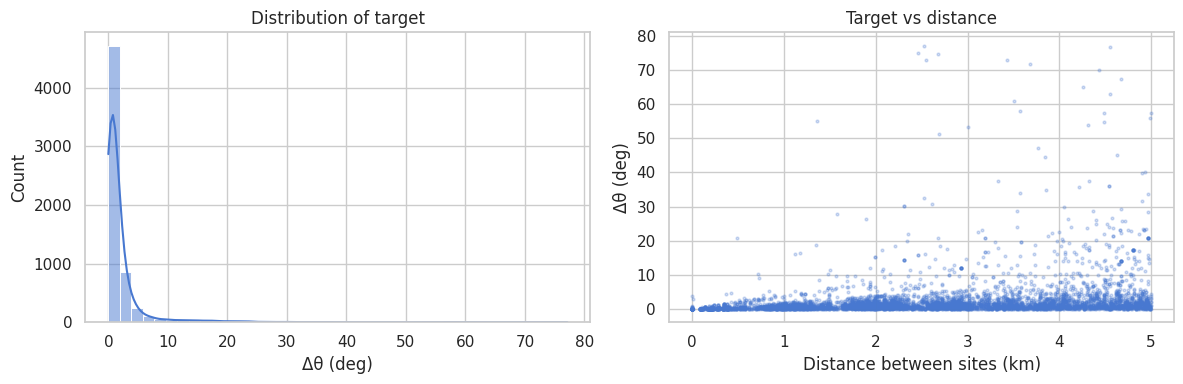

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df[TARGET], bins=40, kde=True, ax=ax[0]); ax[0].set_title("Distribution of target"); ax[0].set_xlabel(LABEL)
ax[1].scatter(df[DIST_COL], df[TARGET], s=4, alpha=.25)
if df[DIST_COL].max() > 10: ax[1].set_xscale("log")
ax[1].set_xlabel("Distance between sites (km)"); ax[1].set_ylabel(LABEL); ax[1].set_title("Target vs distance")
plt.tight_layout(); plt.savefig("results/figures/m2_target_overview.png", dpi=150); plt.show()

## 3. Features
Every numeric column except identifiers and the target is a candidate feature; categorical columns (e.g. NEHRP class) are one-hot encoded. Dummy columns are tracked back to their **original attribute**, so feature selection adds / removes whole attributes. Scaling is fitted inside a `Pipeline`, i.e. on training data only (no leakage).

In [7]:
groups = df[GROUP_COL].values
feat_pre = df.drop(columns=[c for c in DROP_COLS + [TARGET, "delta_theta", "delta_ln_pga", GROUP_COL] if c in df.columns])
cat_cols = feat_pre.select_dtypes(exclude=[np.number]).columns.tolist()
X = pd.get_dummies(feat_pre, columns=cat_cols, drop_first=True, dtype=float)
y = df[TARGET].values
attr_map = {a: [c for c in X.columns if c == a or c.startswith(a + "_")] for a in feat_pre.columns}
assert sum(len(v) for v in attr_map.values()) == X.shape[1], "attribute→column mapping is ambiguous"
print(f"{len(attr_map)} attributes → {X.shape[1]} model columns:", list(attr_map))

15 attributes → 24 model columns: ['site_distance_km', 'magnitude', 'depth_km', 'strike', 'dip', 'rake', 'mechanism', 'avg_pga_g', 'avg_vs30', 'vs30_1', 'vs30_2', 'clstd_1', 'clstd_2', 'nehrp_1', 'nehrp_2']


## 4. Shared train / validation / test split (read, not re-made)

In [8]:
if not os.path.exists(SPLIT_CSV):
    raise FileNotFoundError(f"{SPLIT_CSV} missing - run:  python src/make_split.py")
sp = pd.read_csv(SPLIT_CSV)["split"].values
assert len(sp) == len(df), "split file does not match the pairs file - rerun make_split.py"
train_idx, val_idx, test_idx = [np.where(sp == k)[0] for k in ("train", "val", "test")]
for n, i in [("train", train_idx), ("val", val_idx), ("test", test_idx)]:
    print(f"{n:5s}: {len(i):6d} pairs, {len(np.unique(groups[i])):4d} earthquakes, mean target {y[i].mean():.3f}")
Xtr, Xva, Xte = X.iloc[train_idx], X.iloc[val_idx], X.iloc[test_idx]
ytr, yva, yte = y[train_idx], y[val_idx], y[test_idx]
gtr = groups[train_idx]
SETS = {"train": (Xtr, ytr), "val": (Xva, yva), "test": (Xte, yte)}

train:   4187 pairs,   60 earthquakes, mean target 2.305
val  :   1274 pairs,   13 earthquakes, mean target 1.840
test :    761 pairs,   13 earthquakes, mean target 1.786


## 5. Metrics helper & trivial reference

In [9]:
def metrics(name, split, y_true, y_pred):
    return dict(model=name, split=split, R2=r2_score(y_true, y_pred),
                MAE=mean_absolute_error(y_true, y_pred), RMSE=np.sqrt(mean_squared_error(y_true, y_pred)))
results = [metrics("Mean predictor", s, yy, np.full_like(yy, ytr.mean(), dtype=float)) for s, (_, yy) in SETS.items()]
pd.DataFrame(results).round(4)

,model,split,R2,MAE,RMSE
0,Mean predictor,train,0.0000,2.4641,5.8092
1,Mean predictor,val,-0.0257,1.7283,2.9350
2,Mean predictor,test,-0.0118,2.3525,4.8092


## 6. Benchmark – distance-only linear regression
As in the paper: **Δθ = c₁ + c₂·d** (ordinary least squares on the distance between the two sites only). Any model using the other attributes should beat it.

In [10]:
bench = LinearRegression().fit(Xtr[[DIST_COL]], ytr)
print(f"Benchmark:  Δθ = {bench.intercept_:.3f} + {bench.coef_[0]:.3f} · d(km)")
bench_pred = {s: bench.predict(Xs[[DIST_COL]]) for s, (Xs, _) in SETS.items()}
for s, (_, yy) in SETS.items():
    results.append(metrics("Distance-only benchmark", s, yy, bench_pred[s]))
pd.DataFrame(results).query("model == 'Distance-only benchmark'").round(4)

Benchmark:  Δθ = -0.071 + 0.868 · d(km)


,model,split,R2,MAE,RMSE
3,Distance-only benchmark,train,0.0452,2.3227,5.6764
4,Distance-only benchmark,val,0.1755,1.2078,2.6313
5,Distance-only benchmark,test,0.0834,1.6408,4.5774


## 7. Ridge Regression
Ridge minimises  Σ(yᵢ − βᵀxᵢ)² + α‖β‖²₂ .  The L2 penalty shrinks the coefficients, which stabilises the fit when attributes are correlated (several distance measures, Vs30 of both sites, ...).

### 7.1 Tuning α with all features
5-fold **grouped** cross-validation on the **training** set (a fold never splits an earthquake). The test set is not used for any choice.

all 15 attributes: best α = 2.424e+04, CV R² = -0.1513


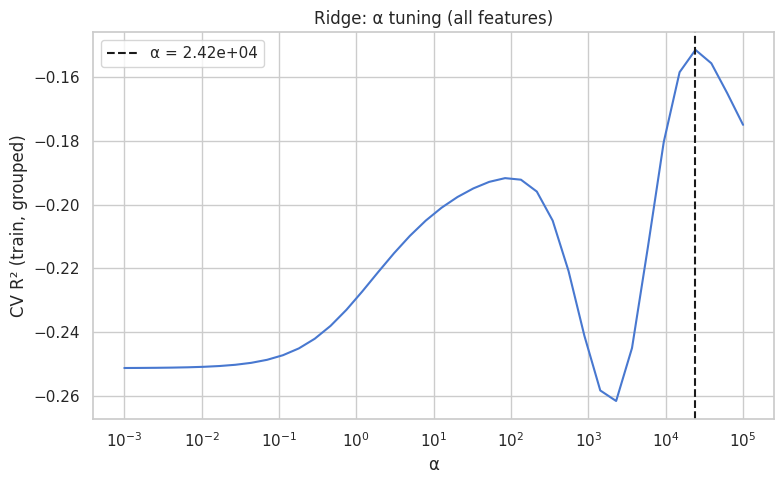

In [11]:
cv = GroupKFold(n_splits=5)
folds = list(cv.split(Xtr, ytr, gtr))

def cv_r2(attrs, alpha):
    cols = [c for a in attrs for c in attr_map[a]]
    sc = []
    for a, b in folds:
        m = Pipeline([("sc", StandardScaler()), ("r", Ridge(alpha=alpha))]).fit(Xtr.iloc[a][cols], ytr[a])
        sc.append(r2_score(ytr[b], m.predict(Xtr.iloc[b][cols])))
    return float(np.mean(sc))

def tune_alpha(attrs):
    scores = [cv_r2(attrs, al) for al in ALPHAS]
    return ALPHAS[int(np.argmax(scores))], np.array(scores)

all_attrs = list(attr_map)
alpha_all, curve_all = tune_alpha(all_attrs)
print(f"all {len(all_attrs)} attributes: best α = {alpha_all:.4g}, CV R² = {curve_all.max():.4f}")
plt.semilogx(ALPHAS, curve_all); plt.axvline(alpha_all, ls="--", c="k", label=f"α = {alpha_all:.3g}")
plt.xlabel("α"); plt.ylabel("CV R² (train, grouped)"); plt.title("Ridge: α tuning (all features)"); plt.legend()
plt.tight_layout(); plt.savefig("results/figures/m2_ridge_alpha_tuning.png", dpi=150); plt.show()
if alpha_all >= ALPHAS[-3]: print("NOTE: best α is at the edge of the grid - widen ALPHAS.")

### 7.2 Backward / forward feature selection (iterated with α)
Following the paper: **backward analysis** ranks each attribute by the drop in R² when it is removed; **forward analysis** then adds attributes one by one in that order and keeps the subset size with the best R². This is repeated together with α tuning (select features → re-tune α → re-select).  
*Difference from the paper:* R² here is the **grouped cross-validated R² on the training set** (the paper used test R², which leaks test information into the model choice).

In [12]:
def backward_rank(attrs, alpha):
    base = cv_r2(attrs, alpha)
    drops = {a: base - cv_r2([x for x in attrs if x != a], alpha) for a in attrs}
    return pd.Series(drops).sort_values(ascending=False)

selected, alpha_sel = all_attrs, alpha_all
for it in range(3):
    rank = backward_rank(all_attrs, alpha_sel)                       # importance of every attribute
    fwd = [cv_r2(list(rank.index[:k]), alpha_sel) for k in range(1, len(rank) + 1)]
    k_best = int(np.argmax(fwd)) + 1
    new_sel = list(rank.index[:k_best])
    new_alpha, _ = tune_alpha(new_sel)
    print(f"iteration {it+1}: {k_best} attributes selected, α = {new_alpha:.4g}, CV R² = {max(fwd):.4f}")
    done = (set(new_sel) == set(selected)) and (new_alpha == alpha_sel)
    selected, alpha_sel = new_sel, new_alpha
    if done: break
print("\nSelected attributes (most → least important):", selected)

iteration 1: 9 attributes selected, α = 2285, CV R² = -0.0489
iteration 2: 2 attributes selected, α = 2285, CV R² = 0.1297
iteration 3: 2 attributes selected, α = 2285, CV R² = 0.1297

Selected attributes (most → least important): ['avg_pga_g', 'site_distance_km']


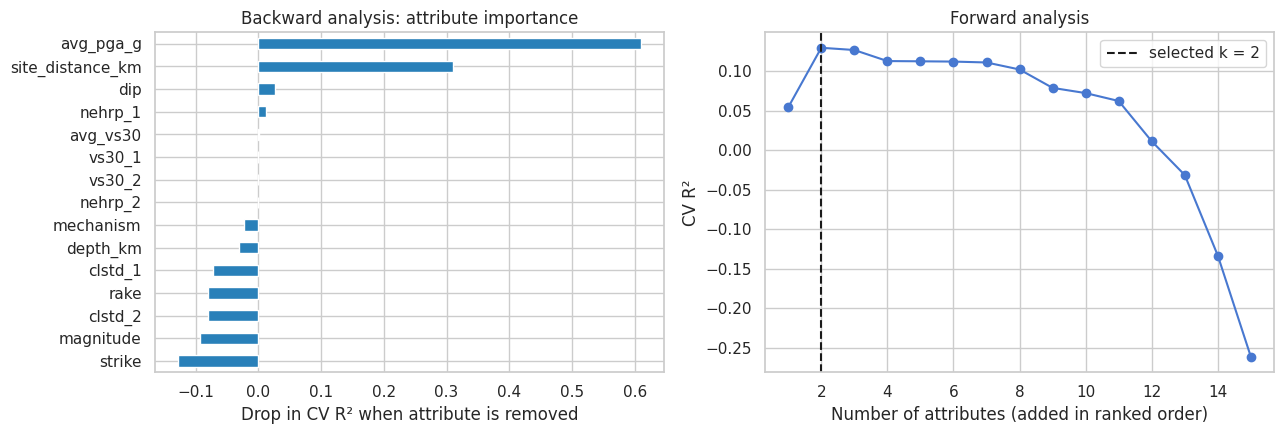

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
rank.iloc[::-1].plot.barh(ax=ax[0], color="#2980b9"); ax[0].set_xlabel("Drop in CV R² when attribute is removed"); ax[0].set_title("Backward analysis: attribute importance")
ax[1].plot(range(1, len(fwd) + 1), fwd, "o-"); ax[1].axvline(k_best, ls="--", c="k", label=f"selected k = {k_best}")
ax[1].set_xlabel("Number of attributes (added in ranked order)"); ax[1].set_ylabel("CV R²"); ax[1].set_title("Forward analysis"); ax[1].legend()
plt.tight_layout(); plt.savefig("results/figures/m2_feature_selection.png", dpi=150); plt.show()
rank.round(4).to_csv("results/feature_ranking_member2.csv", header=["cv_r2_drop"])

### 7.3 Final Ridge models (trained on the training set)

In [14]:
def fit_ridge(attrs, alpha):
    cols = [c for a in attrs for c in attr_map[a]]
    m = Pipeline([("sc", StandardScaler()), ("r", Ridge(alpha=alpha))]).fit(Xtr[cols], ytr)
    return m, cols

ridge_all, cols_all = fit_ridge(all_attrs, alpha_all)
ridge_sel, cols_sel = fit_ridge(selected, alpha_sel)
pred_all = {s: ridge_all.predict(Xs[cols_all]) for s, (Xs, _) in SETS.items()}
pred_sel = {s: ridge_sel.predict(Xs[cols_sel]) for s, (Xs, _) in SETS.items()}
for s, (_, yy) in SETS.items():
    results.append(metrics("Ridge (all features)", s, yy, pred_all[s]))
    results.append(metrics("Ridge (selected features)", s, yy, pred_sel[s]))
res = pd.DataFrame(results)
res.pivot(index="model", columns="split", values=["R2", "MAE"]).round(4)

R2                     MAE                
split                        test   train     val    test   train     val
model                                                                    
Distance-only benchmark    0.0834  0.0452  0.1755  1.6408  2.3227  1.2078
Mean predictor            -0.0118  0.0000 -0.0257  2.3525  2.4641  1.7283
Ridge (all features)       0.1092  0.1166  0.0694  2.0931  2.1362  1.6922
Ridge (selected features)  0.1124  0.2330 -0.0266  2.4980  1.8762  1.9885

## 8. Save results (Member 3 uses `metrics_member2.csv` for the final comparison)

In [15]:
res.round(5).to_csv("results/metrics_member2.csv", index=False)
json.dump({"target": TARGET, "benchmark": f"{TARGET} = {bench.intercept_:.4f} + {bench.coef_[0]:.4f} * distance_km",
           "alpha_all_features": float(alpha_all), "alpha_selected": float(alpha_sel),
           "selected_attributes": selected, "n_model_columns": len(cols_sel), "seed": SEED},
          open("results/ridge_config.json", "w"), indent=2)
joblib.dump({"model": ridge_sel, "columns": cols_sel}, "results/ridge_model.joblib")
print("saved: metrics_member2.csv, ridge_config.json, feature_ranking_member2.csv, ridge_model.joblib")

saved: metrics_member2.csv, ridge_config.json, feature_ranking_member2.csv, ridge_model.joblib


## 9. Robustness – grouped 5-fold cross-validation over all earthquakes
With a limited number of earthquakes one test split can be unrepresentative, so we also report mean ± std over 5 grouped folds (all data). Attributes and α are fixed from section 7, so these numbers are slightly optimistic for Ridge.

In [16]:
rows = []
sel_cols = cols_sel
for k, (a, b) in enumerate(GroupKFold(n_splits=5).split(X, y, groups)):
    pb = LinearRegression().fit(X.iloc[a][[DIST_COL]], y[a]).predict(X.iloc[b][[DIST_COL]])
    pr = clone(ridge_sel).fit(X.iloc[a][sel_cols], y[a]).predict(X.iloc[b][sel_cols])
    for nm, p in [("Distance-only benchmark", pb), ("Ridge (selected features)", pr)]:
        rows.append(dict(fold=k, model=nm, R2=r2_score(y[b], p), MAE=mean_absolute_error(y[b], p)))
cvres = pd.DataFrame(rows)
cvsum = cvres.groupby("model")[["R2", "MAE"]].agg(["mean", "std"]).round(4)
cvres.to_csv("results/cv_member2_folds.csv", index=False); cvsum.to_csv("results/cv_member2_summary.csv")
cvsum

R2             MAE        
                             mean     std    mean     std
model                                                    
Distance-only benchmark    0.0084  0.1302  2.0792  0.4665
Ridge (selected features)  0.1778  0.0709  1.8865  0.6685

## 10. Plots
### 10.1 True vs predicted – training and test (benchmark, then Ridge)

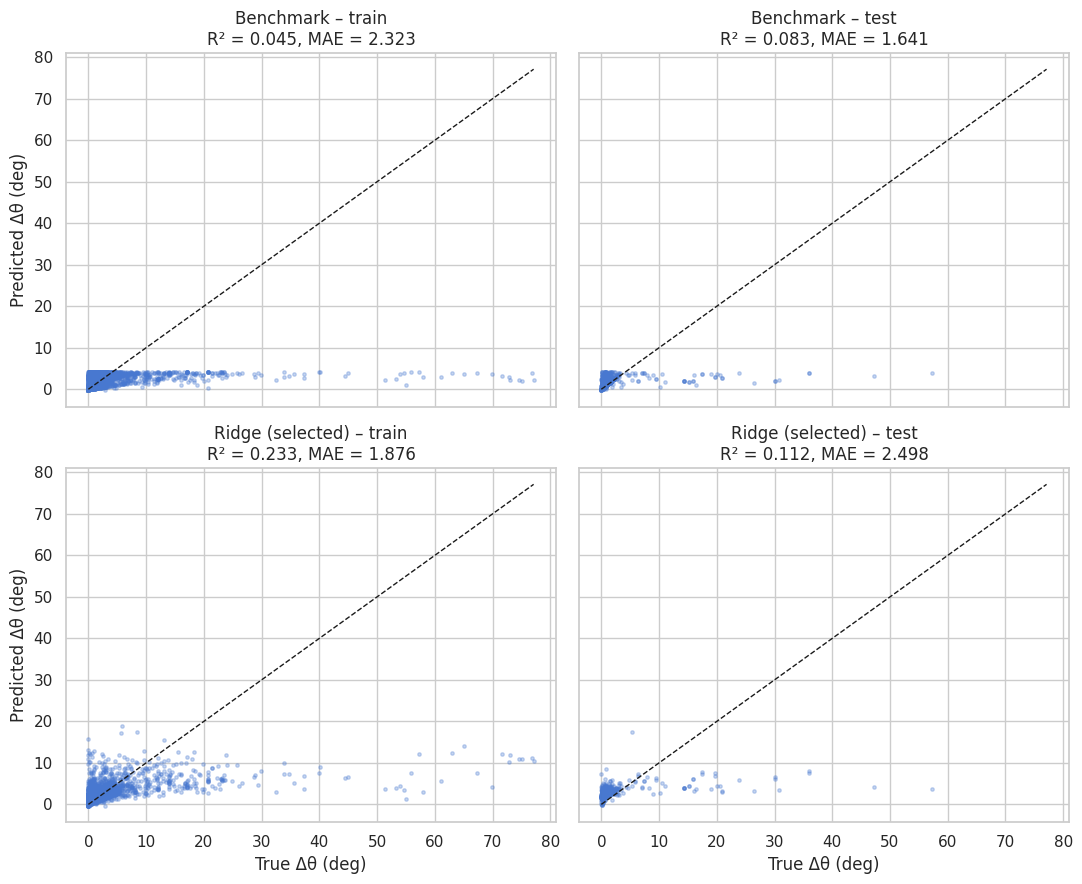

In [17]:
fig, ax = plt.subplots(2, 2, figsize=(11, 9), sharex=True, sharey=True)
lim = [0, max(y.max(), 1)]
for r_, (nm, pr) in enumerate([("Benchmark", bench_pred), ("Ridge (selected)", pred_sel)]):
    for c_, s in enumerate(["train", "test"]):
        yy = SETS[s][1]; p = pr[s]; a = ax[r_, c_]
        a.scatter(yy, p, s=6, alpha=.3); a.plot(lim, lim, "k--", lw=1)
        a.set_title(f"{nm} – {s}\nR² = {r2_score(yy, p):.3f}, MAE = {mean_absolute_error(yy, p):.3f}")
        if r_ == 1: a.set_xlabel("True " + LABEL)
        if c_ == 0: a.set_ylabel("Predicted " + LABEL)
plt.tight_layout(); plt.savefig("results/figures/m2_true_vs_pred.png", dpi=150); plt.show()

### 10.2 Trend plots – target vs distance and vs PGA (binned means, 95% CI; test set)

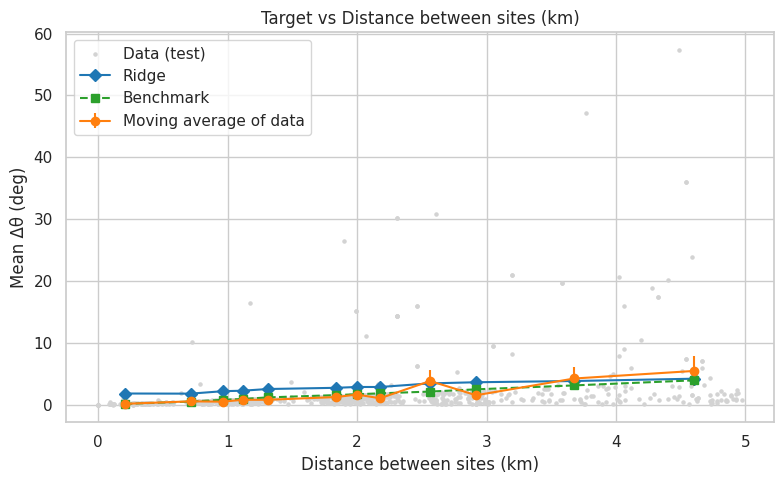

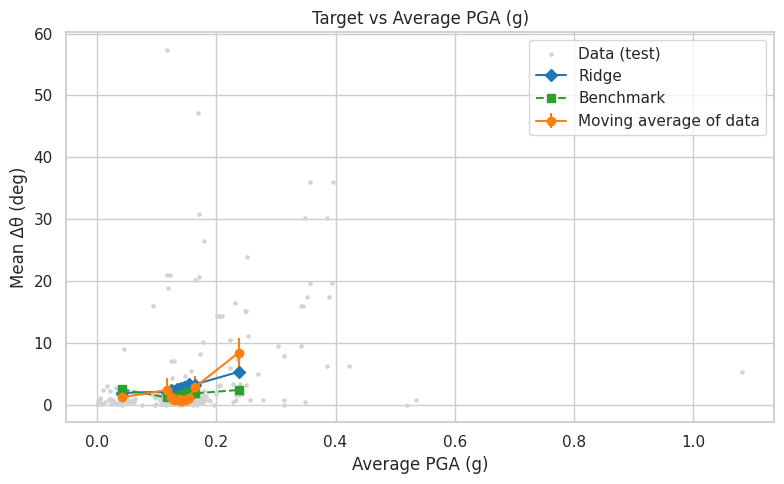

In [18]:
def trend(col, label, fname, q=12):
    t = pd.DataFrame({"x": Xte[col].values, "true": yte, "bench": bench_pred["test"], "ridge": pred_sel["test"]})
    t["bin"] = pd.qcut(t["x"], q=q, duplicates="drop")
    g = t.groupby("bin", observed=True)
    m = g.agg(x=("x", "median"), true=("true", "mean"), bench=("bench", "mean"), ridge=("ridge", "mean"))
    ci = 1.96 * g["true"].std() / np.sqrt(g["true"].count())
    plt.figure(figsize=(8, 5)); plt.scatter(t["x"], t["true"], s=5, c="lightgrey", label="Data (test)")
    plt.errorbar(m.x, m.true, yerr=ci.values, fmt="o-", c="tab:orange", label="Moving average of data")
    plt.plot(m.x, m.ridge, "D-", c="tab:blue", label="Ridge"); plt.plot(m.x, m.bench, "s--", c="tab:green", label="Benchmark")
    plt.xlabel(label); plt.ylabel("Mean " + LABEL); plt.legend(); plt.title(f"Target vs {label}")
    plt.tight_layout(); plt.savefig(f"results/figures/{fname}", dpi=150); plt.show()
trend(DIST_COL, "Distance between sites (km)", "m2_trend_vs_distance.png")
if PGA_COL in Xte.columns: trend(PGA_COL, "Average PGA (g)", "m2_trend_vs_pga.png")

### 10.3 Residuals and Ridge coefficients (selected model)

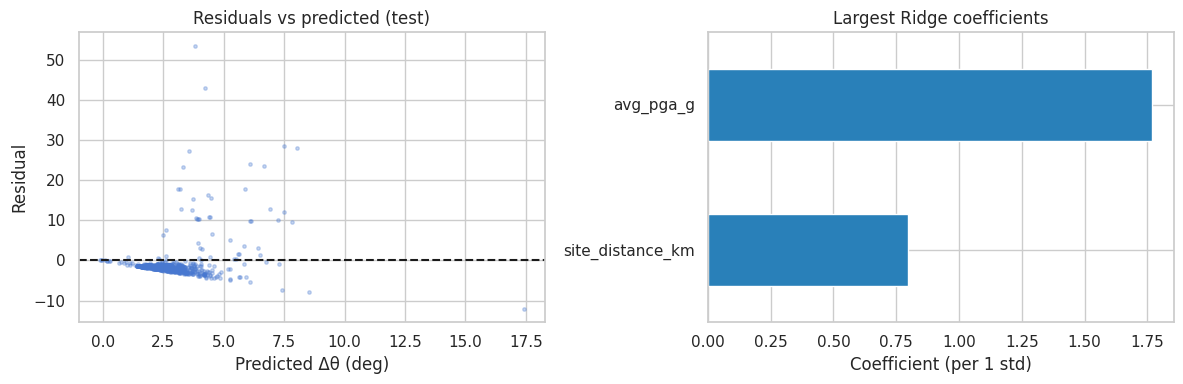

In [19]:
resid = yte - pred_sel["test"]
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].scatter(pred_sel["test"], resid, s=6, alpha=.3); ax[0].axhline(0, c="k", ls="--")
ax[0].set_xlabel("Predicted " + LABEL); ax[0].set_ylabel("Residual"); ax[0].set_title("Residuals vs predicted (test)")
coef = pd.Series(ridge_sel.named_steps["r"].coef_, index=cols_sel).sort_values(key=abs)
coef.tail(12).plot.barh(ax=ax[1], color=np.where(coef.tail(12) > 0, "#2980b9", "#c0392b"))
ax[1].set_xlabel("Coefficient (per 1 std)"); ax[1].set_title("Largest Ridge coefficients")
plt.tight_layout(); plt.savefig("results/figures/m2_ridge_residuals_coefficients.png", dpi=150); plt.show()

## 11. Interpretation (fill in with your final numbers)
Reference (paper, test set): Benchmark R² 0.025 / MAE 20.2 · Ridge R² 0.245 / MAE 16.9 · Neural network R² 0.354 / MAE 13.2.
* **Benchmark:** report c₁, c₂ and test R² / MAE. Does Δθ increase with distance?
* **Ridge vs benchmark:** improvement in R² and MAE; which attributes were selected and why (distance and PGA were the most important in the paper).
* **Train vs test gap:** small gap → regularisation works.
* **CV (section 9):** mean ± std – how stable are the conclusions?
* **Limitations:** linear model; heavy-tailed target; few earthquakes (a single quake can dominate a split); α/feature selection done with CV on the training set; grouped split is stricter than the paper's random split, so scores are expected to be lower.

In [21]:
   from google.colab import files
   !zip -r member2_results.zip results dataset/split_indices.csv
   files.download("member2_results.zip")

updating: results/ (stored 0%)
updating: results/ridge_config.json (deflated 35%)
updating: results/feature_ranking_member2.csv (deflated 39%)
updating: results/cv_member2_summary.csv (deflated 16%)
updating: results/cv_member2_folds.csv (deflated 54%)
updating: results/figures/ (stored 0%)
updating: results/figures/m2_feature_selection.png (deflated 13%)
updating: results/figures/m2_true_vs_pred.png (deflated 13%)
updating: results/figures/m2_ridge_residuals_coefficients.png (deflated 14%)
updating: results/figures/m2_ridge_alpha_tuning.png (deflated 9%)
updating: results/figures/m2_trend_vs_distance.png (deflated 11%)
updating: results/figures/m2_target_overview.png (deflated 9%)
updating: results/figures/m2_trend_vs_pga.png (deflated 13%)
updating: results/metrics_member2.csv (deflated 52%)
updating: results/ridge_model.joblib (deflated 42%)
updating: dataset/split_indices.csv (deflated 76%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>